# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

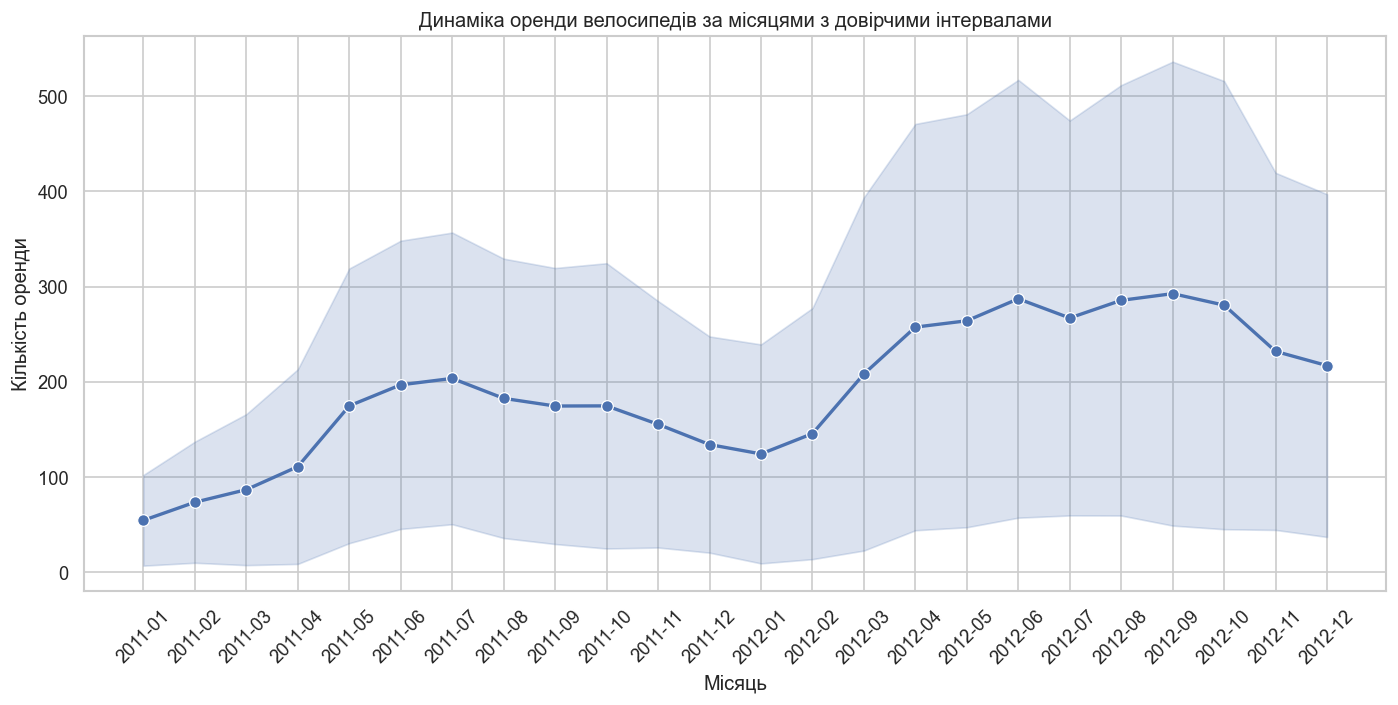

In [16]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str) 

sns.set_theme(style="whitegrid") 

plt.figure(figsize=(14, 6), dpi=120)  # розмір фігури

sns.lineplot(df, x='month_year', y='count', errorbar='sd',
             marker='o', markersize=7, linewidth=2,          
             err_kws={'alpha': 0.2})                        

plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45)
plt.show();

Невизначеність найбільша там, де блакитний інтервал (sd) найширший.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

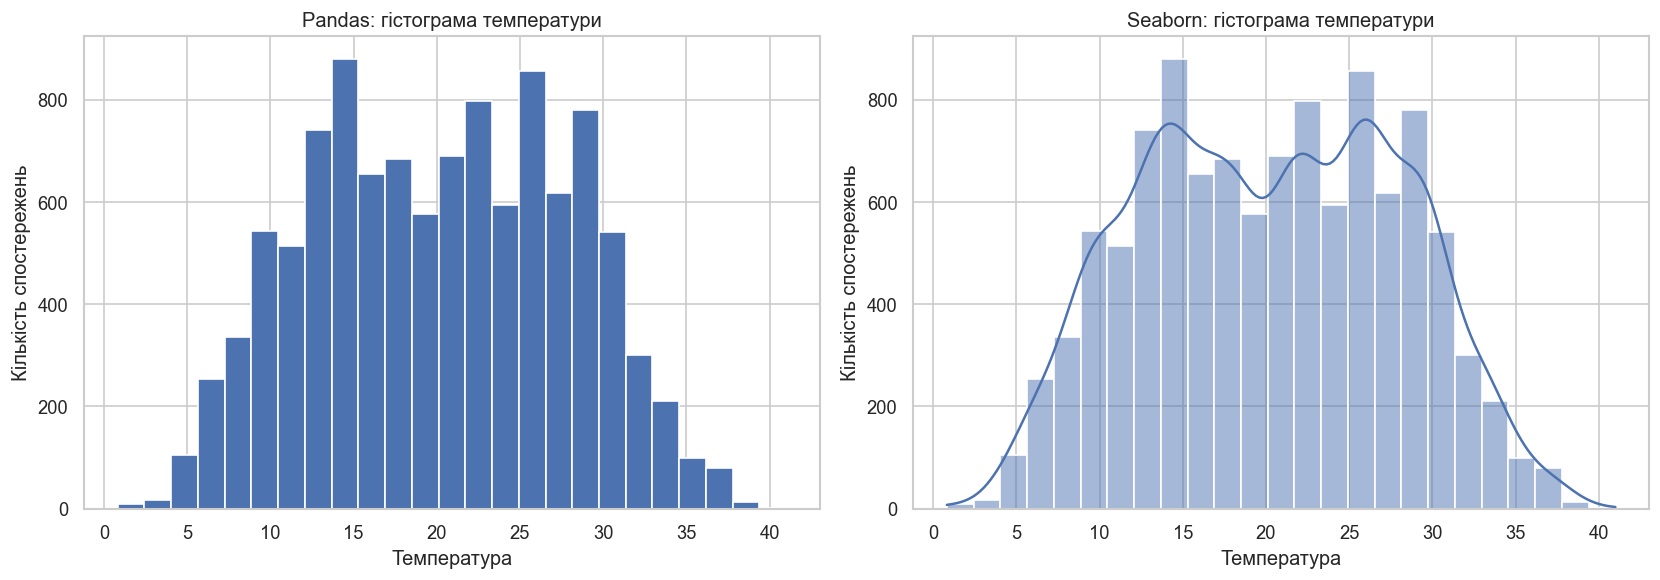

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

bins = 25  

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# 1) Pandas
df["temp"].hist(bins=bins, ax=ax[0])
ax[0].set_title("Pandas: гістограма температури")
ax[0].set_xlabel("Температура")
ax[0].set_ylabel("Кількість спостережень")

# 2) Seaborn
sns.histplot(data=df, x="temp", bins=bins, kde=True, ax=ax[1])
ax[1].set_title("Seaborn: гістограма температури")
ax[1].set_xlabel("Температура")
ax[1].set_ylabel("Кількість спостережень")

plt.tight_layout()
plt.show()

Pandas дає просту гістограму, Seaborn виглядає більш цікаво і ще додає KDE-криву, яка показує загальну форму розподілу (де “пік” і як тягнуться хвости гістограми).

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

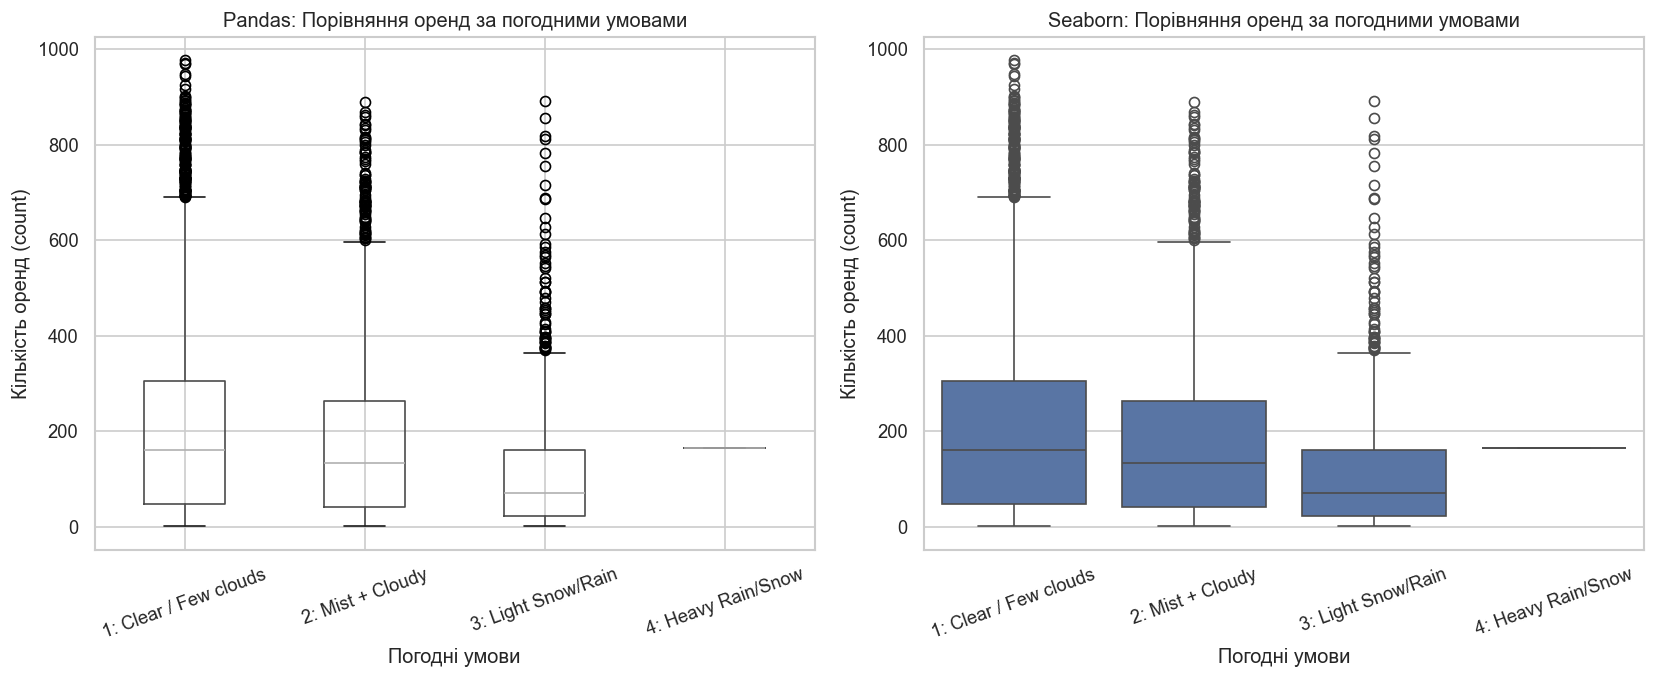

In [21]:

weather_labels = {
    1: "1: Clear / Few clouds",
    2: "2: Mist + Cloudy",
    3: "3: Light Snow/Rain",
    4: "4: Heavy Rain/Snow"
}

# колонка з підписами (щоб однаково було і в Pandas, і в Seaborn)
df["weather_desc"] = df["weather"].map(weather_labels)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 6), dpi=120)


df.boxplot(column="count", by="weather_desc", ax=ax[0])
ax[0].set_title("Pandas: Порівняння оренд за погодними умовами")
ax[0].set_xlabel("Погодні умови")
ax[0].set_ylabel("Кількість оренд (count)")
ax[0].tick_params(axis="x", rotation=20)


sns.boxplot(data=df, x="weather_desc", y="count", ax=ax[1])
ax[1].set_title("Seaborn: Порівняння оренд за погодними умовами")
ax[1].set_xlabel("Погодні умови")
ax[1].set_ylabel("Кількість оренд (count)")
ax[1].tick_params(axis="x", rotation=20)

plt.suptitle("")
plt.tight_layout()
plt.show()

Різниця у забарвленні, розмірах боксів. Seaborn зручніша насприйняття

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


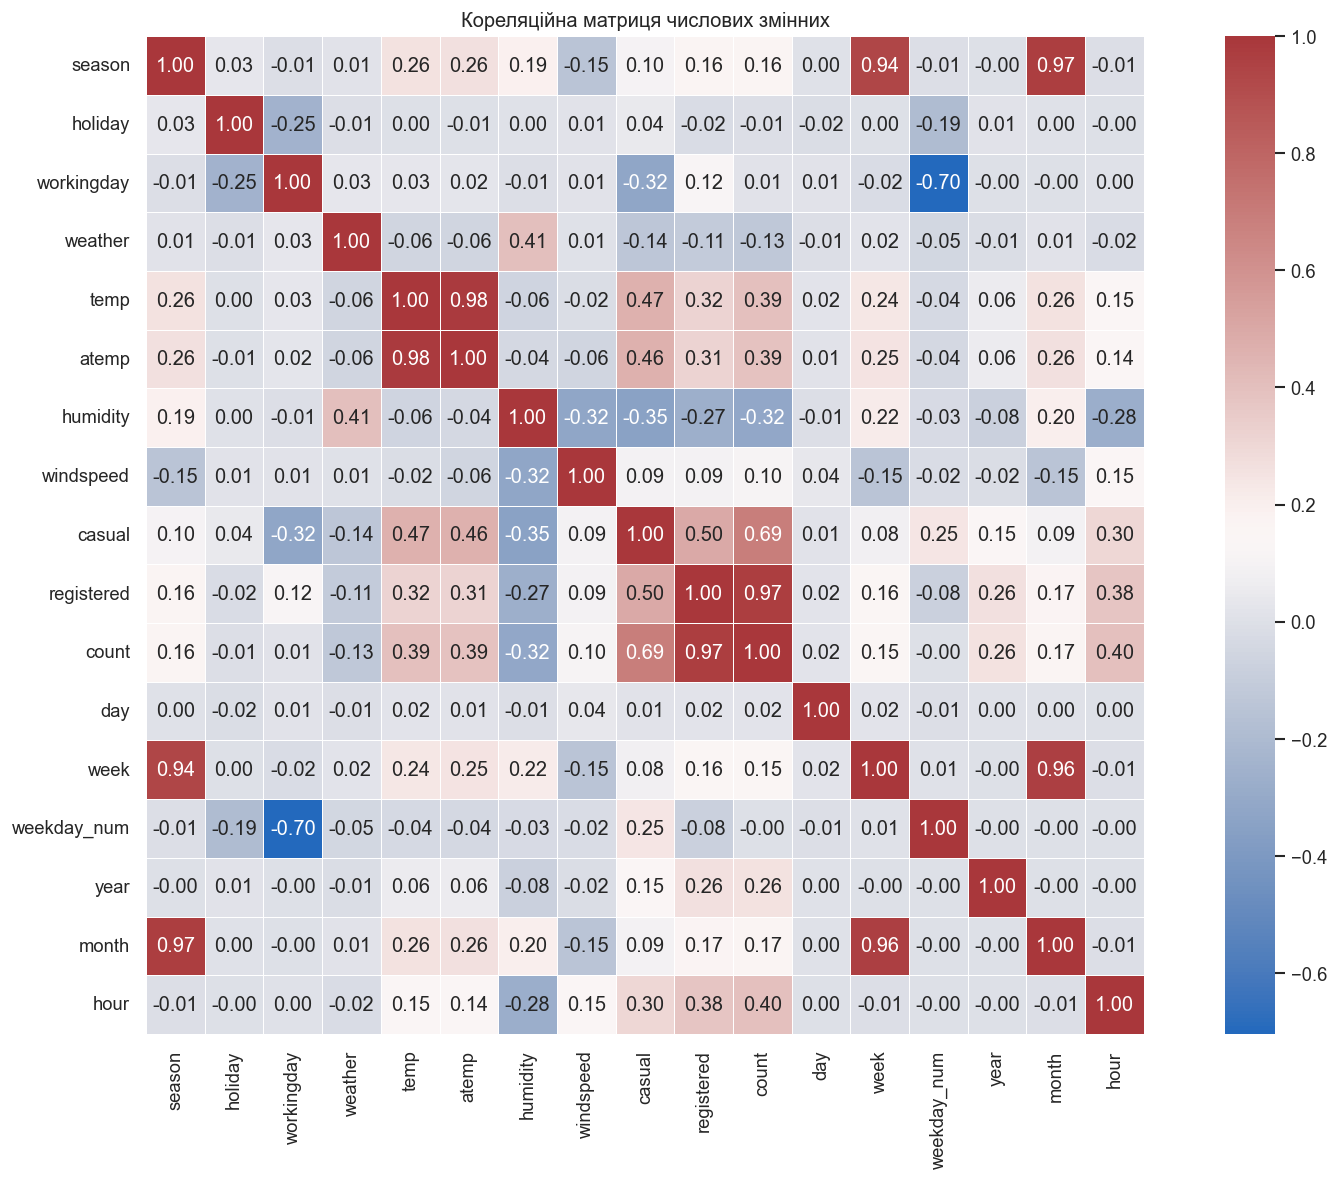

In [27]:

# 1) щоб взяти тільки числові колонки
num_df = df.select_dtypes(include="number")

correlation = num_df.corr()



plt.figure(figsize=(14, 10), dpi=120)
sns.heatmap(
    correlation,
    annot=True,        
    fmt=".2f",
    cmap="vlag",
    linewidths=0.5,
    square=True
)

plt.title("Кореляційна матриця числових змінних")
plt.tight_layout()
plt.show()

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


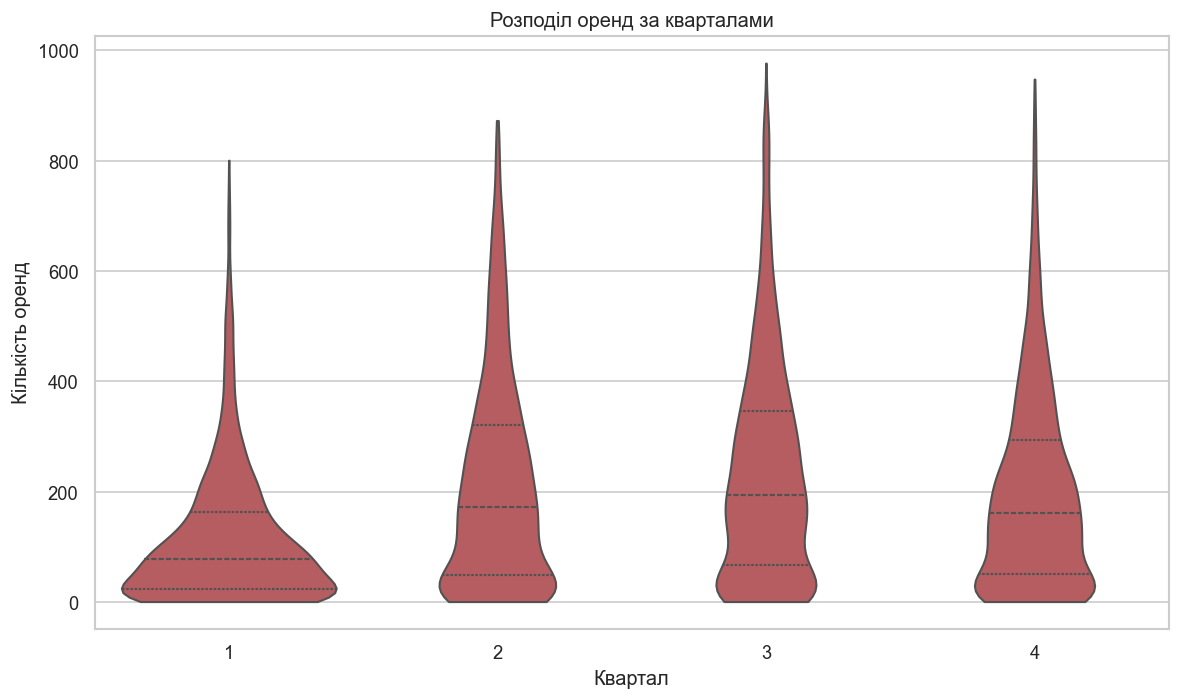

In [33]:
df["quarter"] = df.index.quarter

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6), dpi=120)

sns.violinplot(data=df, x="quarter", y="count", inner="quartile", cut=0, color = 'r')

plt.title("Розподіл оренд за кварталами")
plt.xlabel("Квартал")
plt.ylabel("Кількість оренд")
plt.tight_layout()
plt.show()

1. Там де “violin” ширша, там більше спостережень , тобто це найтиповіші значення.

2. Найбільше коливання оренди — у 3 кварталі (Q3): там найширший розкид значень і більше великих піків.

3. Перевага violin plot над box plot у тому, що він показує не лише медіану й квартилі, а ще й чи є піки, де саме зосереджені значення.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

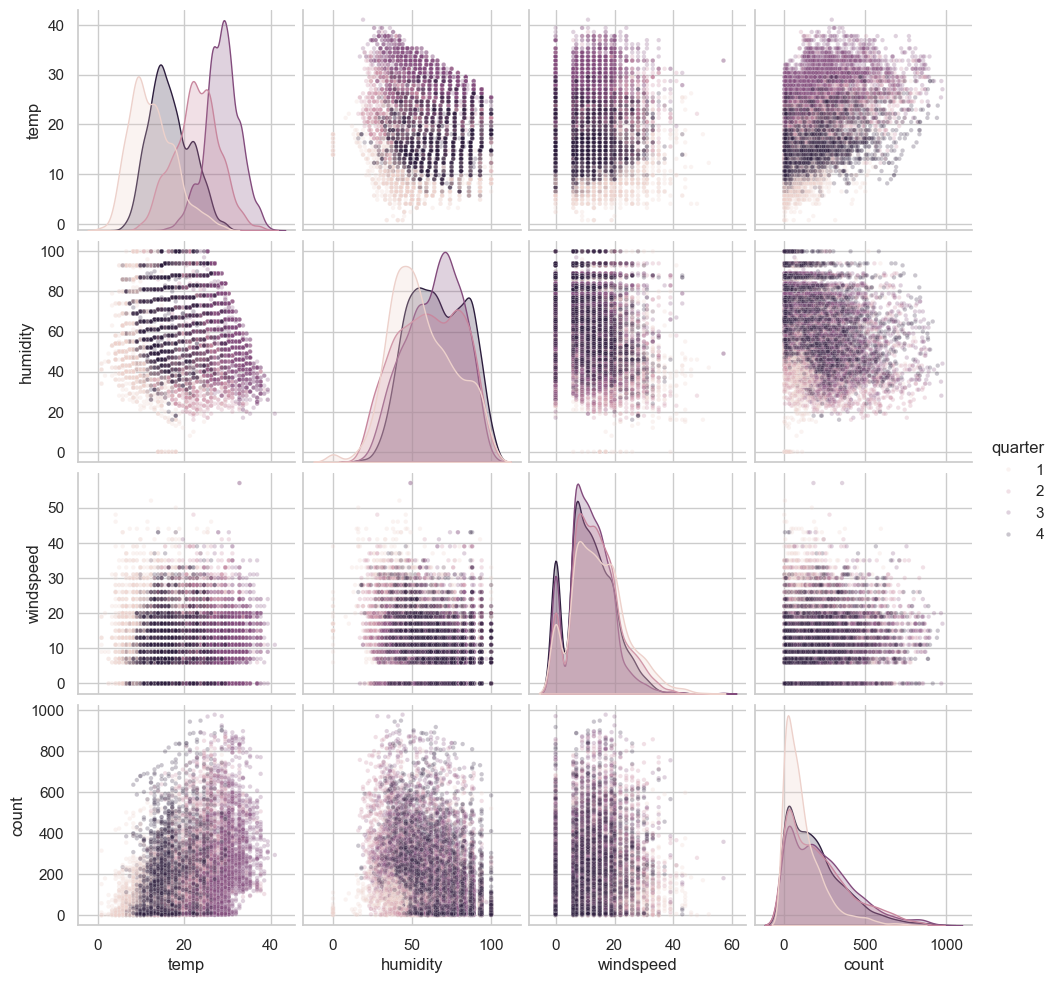

In [37]:

df["quarter"] = df.index.quarter

sns.set_theme(style="whitegrid")

sns.pairplot(
    data=df,
    vars=["temp", "humidity", "windspeed", "count"],
    hue="quarter",
    diag_kind="kde",
    plot_kws={"alpha": 0.25, "s": 10}
)
plt.show()

1. Найсильніший зв’язок: між temp і count — тепліше  = оренд більше.

2. Найбільше різниться між кварталами температура.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

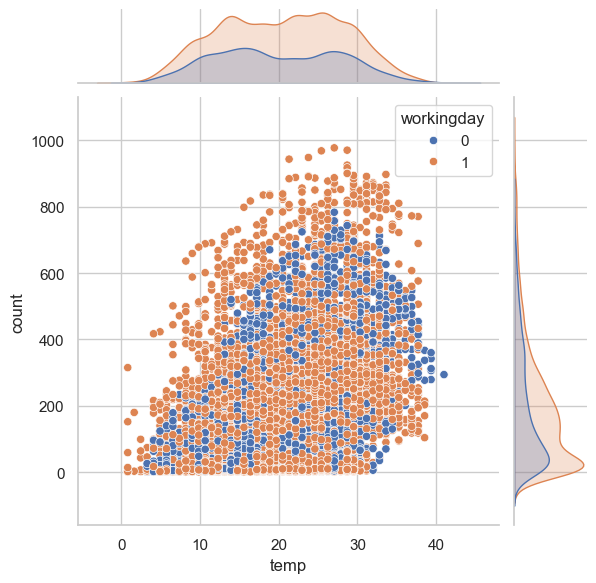

In [38]:
sns.jointplot(data=df, x="temp", y="count", hue="workingday");

In [39]:
1. По краях графіки  показують таке: зверху - це  як часто зустрічаються значення температури; справа —  це як часто зустрічаються значення кількості оренд 

2. Так. У робочі дні оренд зазвичай більше, температура майже не відрізняється.

SyntaxError: invalid character '—' (U+2014) (1838306404.py, line 1)